# Visualisasi Data dengan Python

**Mata Kuliah:** Data Insight  
**Program:** Magister Informatika, Universitas Islam Indonesia  
**Dosen:** Ahmad Fathan Hidayatullah, PhD

Notebook ini berisi tutorial ringkas visualisasi data dengan Python. Materi disusun dengan mengacu pada PDF *Data Visualization with Python - GeeksforGeeks* yang membahas penggunaan Matplotlib, Seaborn, Bokeh, dan Plotly. Fokus utama notebook ini adalah **Matplotlib** sebagai dasar visualisasi data.

## 1. Tujuan Pembelajaran

Setelah mengikuti tutorial ini, mahasiswa diharapkan mampu:

1. Menjelaskan peran visualisasi data dalam analisis data.
2. Mengenal beberapa library visualisasi data pada Python.
3. Memahami anatomi dasar grafik pada Matplotlib.
4. Membuat scatter plot, line plot, bar chart, dan histogram.
5. Melakukan kustomisasi grafik menggunakan Matplotlib.
6. Membandingkan penggunaan Matplotlib dengan Seaborn, Bokeh, dan Plotly secara ringkas.

## 2. Persiapan Library

Library yang digunakan:

- `pandas` untuk membaca dan mengelola data.
- `matplotlib` untuk visualisasi dasar.
- `seaborn` untuk visualisasi statistik yang lebih ringkas.
- `bokeh` dan `plotly` untuk visualisasi interaktif.

Jika library belum tersedia, jalankan perintah berikut pada terminal atau notebook:

```bash
pip install pandas matplotlib seaborn bokeh plotly
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pengaturan agar plot tampil di notebook
%matplotlib inline

## 3. Dataset

PDF acuan menggunakan dataset **tips**, yaitu data transaksi restoran yang berisi beberapa variabel seperti `total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, dan `size`.

Agar notebook ini dapat dijalankan secara mandiri, sel berikut akan mencoba membaca file `tips.csv`. Jika file tersebut belum tersedia, notebook akan membuat data contoh dengan struktur yang mirip.

In [2]:
from pathlib import Path

csv_path = Path('tips.csv')

if csv_path.exists():
    data = pd.read_csv(csv_path)
else:
    np.random.seed(42)
    n = 244
    days = np.random.choice(['Thur', 'Fri', 'Sat', 'Sun'], size=n, p=[0.25, 0.15, 0.35, 0.25])
    sex = np.random.choice(['Male', 'Female'], size=n)
    smoker = np.random.choice(['Yes', 'No'], size=n, p=[0.38, 0.62])
    time = np.where(np.isin(days, ['Thur', 'Fri']),
                    np.random.choice(['Lunch', 'Dinner'], size=n, p=[0.65, 0.35]),
                    'Dinner')
    size = np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.04, 0.55, 0.16, 0.18, 0.04, 0.03])
    total_bill = np.round(np.random.gamma(shape=5, scale=4, size=n) + size * 2, 2)
    tip = np.round(total_bill * np.random.uniform(0.08, 0.22, size=n), 2)

    data = pd.DataFrame({
        'total_bill': total_bill,
        'tip': tip,
        'sex': sex,
        'smoker': smoker,
        'day': days,
        'time': time,
        'size': size
    })
    data.to_csv(csv_path, index=False)

data.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,17.68,2.07,Male,No,Fri,Lunch,2
1,34.94,4.56,Male,No,Sun,Dinner,2
2,35.83,3.31,Female,Yes,Sat,Dinner,1
3,18.16,3.83,Male,Yes,Sat,Dinner,2
4,18.29,2.88,Male,Yes,Thur,Dinner,2
5,28.69,3.52,Female,Yes,Thur,Dinner,2
6,43.49,5.90,Male,Yes,Thur,Lunch,4
7,42.88,6.12,Male,No,Sun,Dinner,2
8,17.86,2.93,Male,Yes,Sat,Dinner,2
9,19.51,2.97,Female,Yes,Sat,Dinner,2


## 4. Pengenalan Visualisasi Data dengan Python

Visualisasi data membantu analis memahami pola dan informasi penting yang mungkin sulit terlihat jika data hanya disajikan dalam bentuk tabel. Dalam Python, terdapat beberapa library populer untuk visualisasi data:

| Library | Karakteristik Utama | Contoh Penggunaan |
|---|---|---|
| Matplotlib | Dasar, fleksibel, sangat dapat dikustomisasi | Grafik statis, laporan, eksplorasi awal |
| Seaborn | Dibangun di atas Matplotlib, lebih ringkas dan menarik | Visualisasi statistik |
| Bokeh | Interaktif dan berbasis web | Dashboard interaktif |
| Plotly | Interaktif, modern, mendukung hover dan zoom | Dashboard, eksplorasi data interaktif |

Dalam praktik analisis data, Matplotlib sering dipelajari terlebih dahulu karena menjadi fondasi bagi banyak library visualisasi lain.

## 5. Anatomi Dasar Matplotlib

Matplotlib memiliki beberapa komponen penting:

- **Figure**: kanvas utama tempat grafik dibuat.
- **Axes**: area tempat data diplot.
- **Axis**: sumbu X dan Y.
- **Title**: judul grafik.
- **Label**: keterangan pada sumbu.
- **Legend**: keterangan untuk membedakan beberapa data dalam satu grafik.

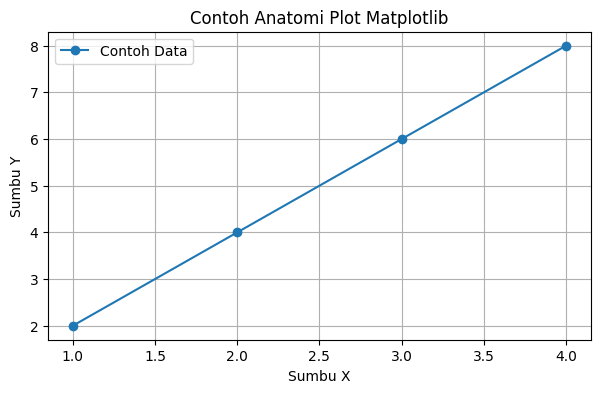

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot([1, 2, 3, 4], [2, 4, 6, 8], marker='o', label='Contoh Data')
ax.set_title('Contoh Anatomi Plot Matplotlib')
ax.set_xlabel('Sumbu X')
ax.set_ylabel('Sumbu Y')
ax.legend()
ax.grid(True)

plt.show()

## 6. Scatter Plot

Scatter plot digunakan untuk melihat hubungan antara dua variabel numerik. Pada contoh berikut, kita melihat hubungan antara `total_bill` dan `tip`.

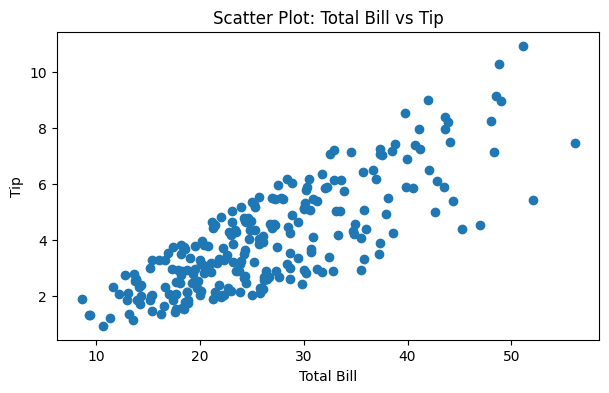

In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(data['total_bill'], data['tip'])

plt.title('Scatter Plot: Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

plt.show()

### Scatter Plot dengan Kustomisasi

Pada contoh berikut:

- Warna titik menunjukkan jumlah orang dalam satu meja (`size`).
- Ukuran titik juga dibuat proporsional terhadap nilai `total_bill`.
- `colorbar()` digunakan untuk membantu membaca makna warna.

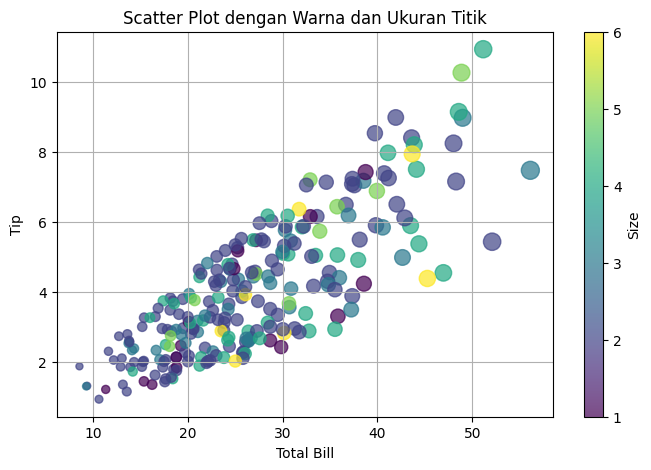

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(
    data['total_bill'],
    data['tip'],
    c=data['size'],
    s=data['total_bill'] * 3,
    alpha=0.7
)

plt.title('Scatter Plot dengan Warna dan Ukuran Titik')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.colorbar(label='Size')
plt.grid(True)

plt.show()

## 7. Line Plot

Line plot digunakan untuk menunjukkan perubahan nilai berdasarkan urutan data. Dalam contoh ini, kita menampilkan nilai `tip` berdasarkan indeks data.

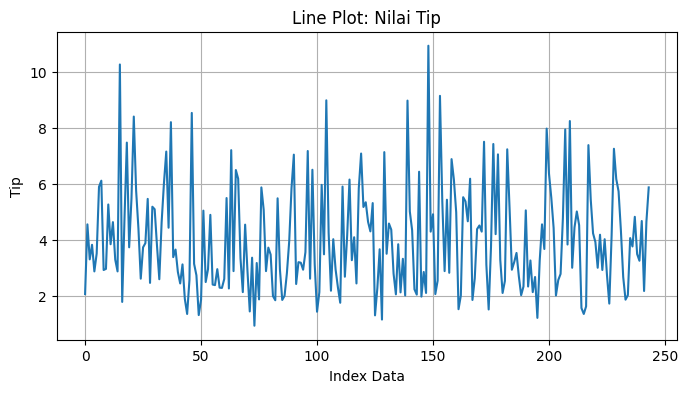

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(data['tip'])

plt.title('Line Plot: Nilai Tip')
plt.xlabel('Index Data')
plt.ylabel('Tip')
plt.grid(True)

plt.show()

### Multiple Line Plot

Beberapa garis dapat ditampilkan dalam satu grafik untuk membandingkan variabel.

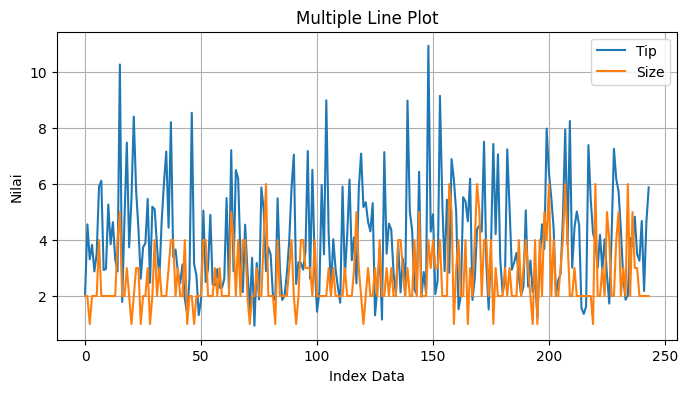

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(data['tip'], label='Tip')
plt.plot(data['size'], label='Size')

plt.title('Multiple Line Plot')
plt.xlabel('Index Data')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)

plt.show()

## 8. Bar Chart

Bar chart digunakan untuk membandingkan nilai berdasarkan kategori. Agar lebih informatif, data dikelompokkan berdasarkan hari, kemudian dihitung rata-rata `tip` untuk setiap hari.

In [8]:
avg_tip_by_day = data.groupby('day', as_index=False)['tip'].mean()
avg_tip_by_day

,day,tip
0,Fri,3.677250
1,Sat,3.949868
2,Sun,4.265763
3,Thur,4.035362


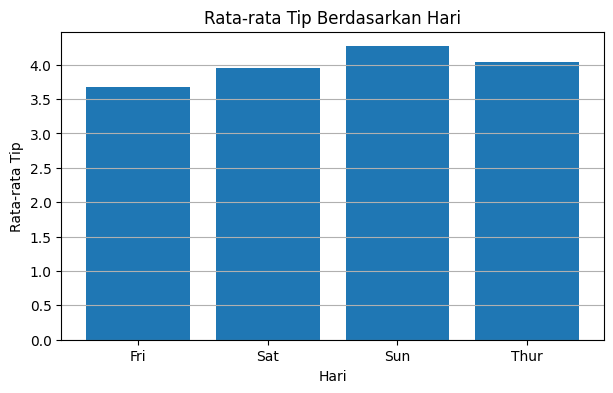

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(avg_tip_by_day['day'], avg_tip_by_day['tip'])

plt.title('Rata-rata Tip Berdasarkan Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Tip')
plt.grid(axis='y')

plt.show()

## 9. Pie Plot

Pie plot digunakan untuk menampilkan komposisi atau proporsi dari beberapa kategori. Grafik ini sesuai ketika jumlah kategori tidak terlalu banyak dan setiap bagian merupakan bagian dari satu total keseluruhan.

Pada contoh berikut, pie plot digunakan untuk melihat proporsi jumlah transaksi berdasarkan hari pada dataset `tips`.

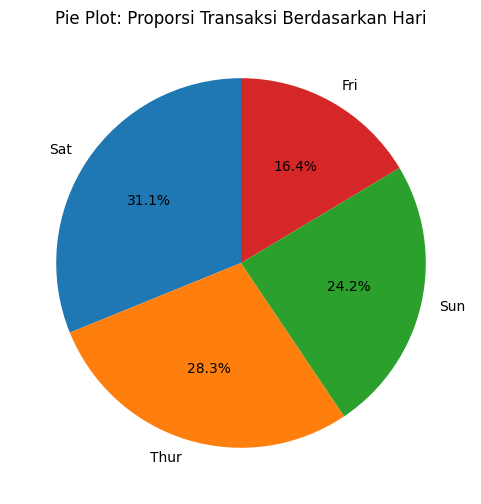

In [10]:
# Menghitung jumlah transaksi berdasarkan hari
transactions_by_day = data['day'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    transactions_by_day,
    labels=transactions_by_day.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Pie Plot: Proporsi Transaksi Berdasarkan Hari')
plt.show()

**Interpretasi:**

- Setiap irisan menunjukkan proporsi transaksi pada masing-masing hari.
- `autopct` digunakan untuk menampilkan persentase pada setiap bagian.
- Pie plot sebaiknya digunakan untuk komposisi sederhana, bukan untuk membandingkan banyak kategori secara detail.

## 10. Histogram

Histogram digunakan untuk melihat distribusi data numerik. Contoh berikut menampilkan distribusi `total_bill`.

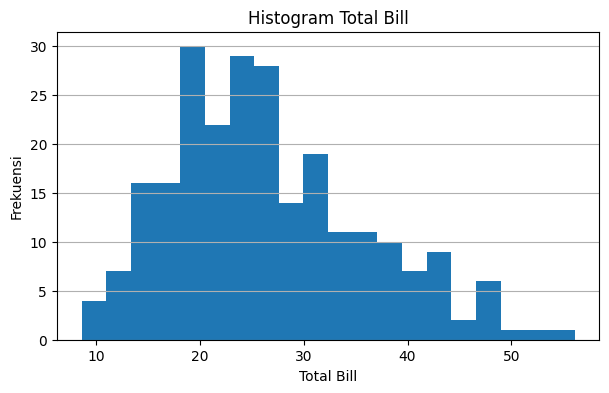

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(data['total_bill'], bins=20)

plt.title('Histogram Total Bill')
plt.xlabel('Total Bill')
plt.ylabel('Frekuensi')
plt.grid(axis='y')

plt.show()

## 11. 3D Plot

3D plot digunakan untuk menampilkan hubungan antara tiga variabel numerik. Pada Matplotlib, 3D plot dapat dibuat dengan bantuan modul `mpl_toolkits.mplot3d`.

Pada contoh berikut, visualisasi 3D digunakan untuk melihat hubungan antara `total_bill`, `tip`, dan `size`.

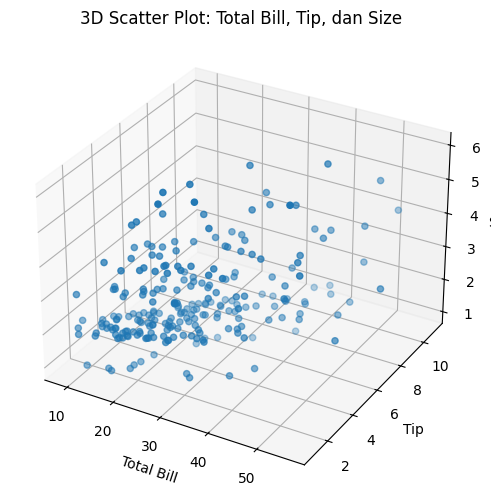

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['total_bill'],
    data['tip'],
    data['size']
)

ax.set_title('3D Scatter Plot: Total Bill, Tip, dan Size')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')
ax.set_zlabel('Size')

plt.show()

**Interpretasi:**

- Sumbu X menunjukkan nilai `total_bill`.
- Sumbu Y menunjukkan nilai `tip`.
- Sumbu Z menunjukkan ukuran rombongan atau `size`.
- 3D plot berguna untuk eksplorasi awal, tetapi perlu digunakan secara hati-hati karena sudut pandang dapat memengaruhi pembacaan grafik.

## 12. Plot Customization pada Matplotlib

Matplotlib menyediakan banyak opsi kustomisasi, seperti warna, marker, gaya garis, ukuran figure, label, legend, dan grid.

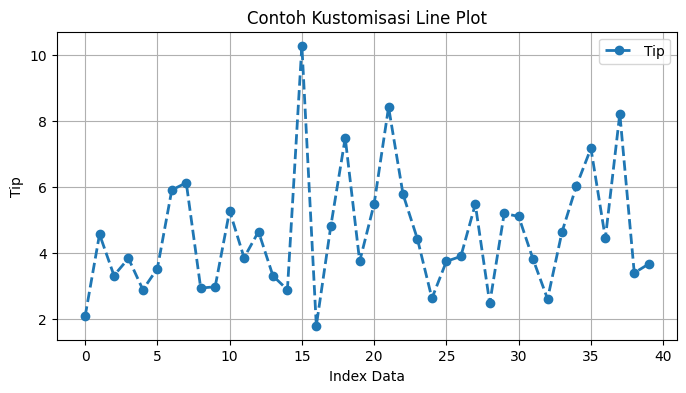

In [13]:
plt.figure(figsize=(8, 4))

plt.plot(
    data['tip'].head(40),
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Tip'
)

plt.title('Contoh Kustomisasi Line Plot')
plt.xlabel('Index Data')
plt.ylabel('Tip')
plt.legend()
plt.grid(True)

plt.show()

## 13. Subplot

Subplot digunakan untuk menampilkan beberapa grafik dalam satu figure. Cara ini berguna ketika ingin membandingkan beberapa visualisasi sekaligus.

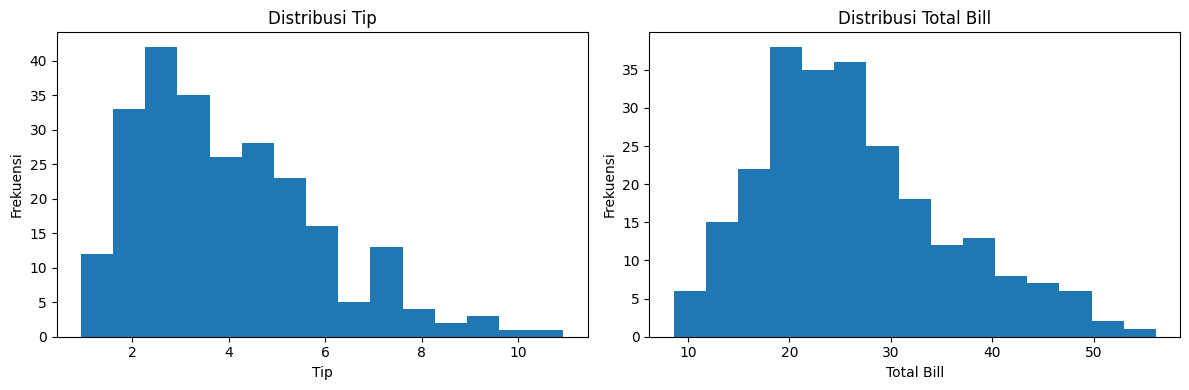

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(data['tip'], bins=15)
ax[0].set_title('Distribusi Tip')
ax[0].set_xlabel('Tip')
ax[0].set_ylabel('Frekuensi')

ax[1].hist(data['total_bill'], bins=15)
ax[1].set_title('Distribusi Total Bill')
ax[1].set_xlabel('Total Bill')
ax[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## 14. Seaborn Secara Singkat

Seaborn menyediakan cara yang lebih ringkas untuk membuat visualisasi statistik. Library ini dibangun di atas Matplotlib, sehingga fungsi Matplotlib tetap dapat digunakan untuk menambahkan judul, label, atau elemen lain.

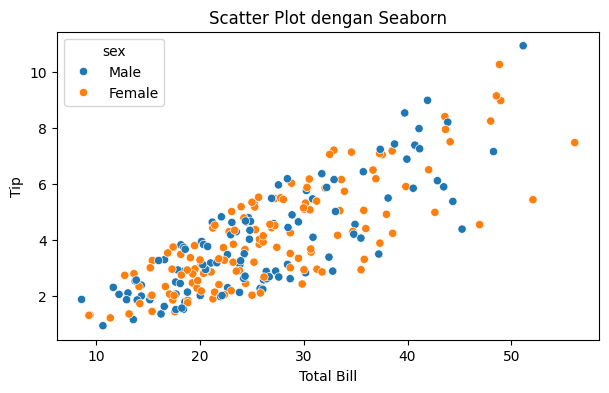

In [15]:
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.scatterplot(x='total_bill', y='tip', hue='sex', data=data)

plt.title('Scatter Plot dengan Seaborn')
plt.xlabel('Total Bill')
plt.ylabel('Tip')

plt.show()

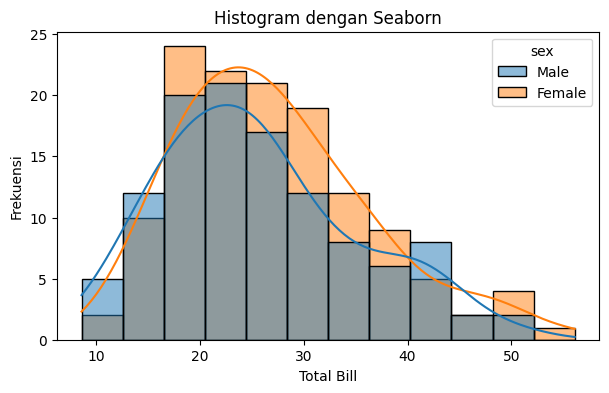

In [16]:
plt.figure(figsize=(7, 4))
sns.histplot(x='total_bill', data=data, kde=True, hue='sex')

plt.title('Histogram dengan Seaborn')
plt.xlabel('Total Bill')
plt.ylabel('Frekuensi')

plt.show()

## 15. Bokeh Secara Singkat

Bokeh digunakan untuk membuat visualisasi interaktif berbasis web. Jalankan kode berikut di notebook untuk melihat hasil interaktifnya.

In [17]:
from bokeh.plotting import figure, show, output_notebook

output_notebook()

p = figure(title='Bokeh Scatter Plot', width=700, height=400)
p.scatter(data['total_bill'], data['tip'], size=8, alpha=0.6)
p.xaxis.axis_label = 'Total Bill'
p.yaxis.axis_label = 'Tip'

show(p)

Loading BokehJS ...

## 16. Plotly Secara Singkat

Plotly juga mendukung grafik interaktif. Kelebihannya adalah fitur seperti hover, zoom, dan eksplorasi data yang lebih mudah.

In [18]:
import plotly.express as px

fig = px.scatter(
    data,
    x='total_bill',
    y='tip',
    color='sex',
    size='size',
    title='Plotly Scatter Plot: Total Bill vs Tip'
)

fig.show()

## 17. Latihan Mandiri

Kerjakan latihan berikut:

1. Buat scatter plot antara `total_bill` dan `tip`, kemudian bedakan warna titik berdasarkan `smoker`.
2. Buat bar chart rata-rata `total_bill` berdasarkan `day`.
3. Buat histogram untuk variabel `tip`.
4. Buat dua subplot: satu untuk histogram `tip`, satu untuk histogram `total_bill`.
5. Gunakan Seaborn untuk membuat scatter plot dengan parameter `hue='time'`.

Tuliskan interpretasi singkat untuk setiap visualisasi.

## 18. Kesimpulan

Visualisasi data membantu analis memahami pola, tren, dan hubungan antarvariabel secara lebih mudah. Python menyediakan beberapa library visualisasi, seperti Matplotlib, Seaborn, Bokeh, dan Plotly.

Matplotlib penting dipelajari karena menjadi dasar visualisasi di Python. Dengan memahami Figure, Axes, label, title, legend, grid, dan berbagai jenis plot dasar, mahasiswa akan lebih siap menggunakan library visualisasi lain yang lebih tinggi tingkatnya.

## Referensi

1. GeeksforGeeks. *Data Visualization with Python*. PDF acuan utama pada tutorial ini.
2. Matplotlib Documentation.
3. Seaborn Documentation.
4. Bokeh Documentation.
5. Plotly Documentation.